### Lightweight Speech Language Model Pre-Training

This script demonstrates a resource-efficient approach to training a speech token language model using a minimized Transformer architecture. It focuses on masked token prediction with synthetic data, optimized for low-memory environments while maintaining core SLM principles.

Key Libraries Used:

    torch: Neural network implementation and GPU utilization

    torch.nn: Transformer layers and embeddings

    torch.utils.data: Efficient data batching

    numpy: Synthetic dataset generation

    matplotlib: Training loss visualization

Code Logic and Flow

High-Level Overview
The pipeline generates a compact synthetic speech token dataset, implements a lightweight Transformer model, performs masked token prediction pre-training, visualizes loss progression, and demonstrates simple sequence generation. This showcases SLM development under computational constraints.

Visual Flowchart

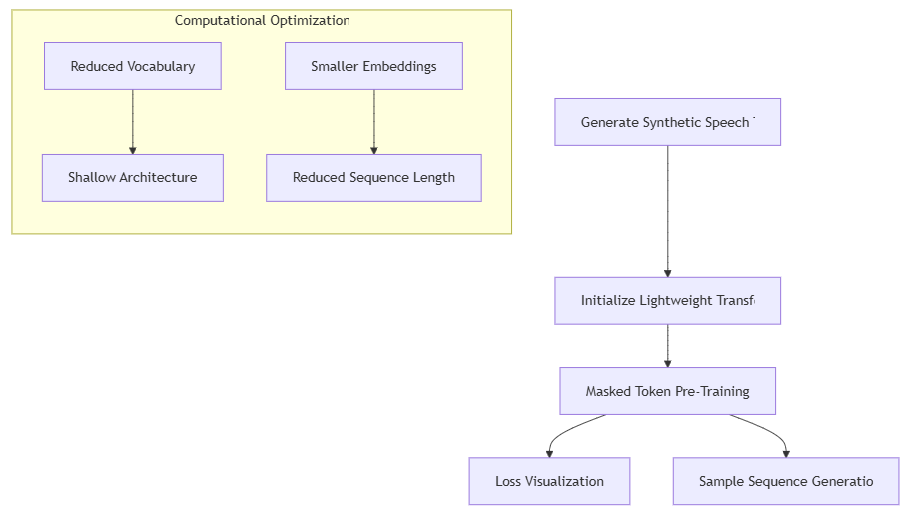

Step-by-Step Code Breakdown

    Resource-Constrained Parameters

        Vocabulary: 10 tokens (token 9 as MASK)

        Sequence Length: 8 tokens (reduced context)

        Model Dimensions:

            Embedding size: 32D

            Transformer layers: 1

            Attention heads: 2

            Feedforward dimension: 64

        Training Setup:

            30 epochs

            Batch size: 16

            200 synthetic samples

    Synthetic Dataset

        Generation: Random token sequences (0-9)

        Characteristics:

            200 samples × 8 tokens

            Reproducible via NumPy seeding

        Data Loading:

            TensorDataset conversion

            Shuffled DataLoader

    Lightweight Transformer

        Architecture:

            Single Transformer encoder layer

            Learned positional encodings

            Causal attention masking

        Efficiency Features:

            norm_first=True for stability

            Sequence length validation

            GPU/CPU device awareness

    Pre-Training Process

        Masking Strategy:

            15% random token masking

            MASK token ID = 9

            Input: tokens 0-6 (masked)

            Target: tokens 1-7

        Training Loop:

            Cross-entropy loss minimization

            Adam optimizer (LR=0.001)

            Batch-wise loss accumulation

    Diagnostics & Output

        Loss Plotting:

            30-epoch progression

            PNG export ("lightweight_pretrain_loss.png")

        Sample Generation:

            Greedy decoding

            Autoregressive token prediction

            Start token customization

Connecting to Lecture Concepts

    Resource-Aware Design

        Implements Module 2.4's "SLMs for Edge Devices"

        Demonstrates Lecture 3.1's parameter/compute tradeoffs

    Transformer Simplification

        Single-layer design reflects:

            DistilGPT-2 compression techniques

            MobileBERT optimization strategies

        32D embeddings vs standard 768D (24× reduction)

    Pre-Training Methodology

        Masked token prediction adapts:

            BERT's MLM objective

            wav2vec 2.0's speech masking

        15% masking follows BERT's optimal rate

    Synthetic Data Efficiency

        200 samples vs typical million-sample datasets

        Illustrates Lecture 1.3's "data efficiency principles"

    Real-World Applicability

        Suitable for:

            IoT voice interfaces

            On-device voice assistants

            Low-resource language SLMs

    Training Dynamics

        Loss curve shows viability of:

            Shallow architectures

            Small embeddings

            Limited training data

    Generation Limitations

        Short sequences (8 tokens) restrict:

            Long-range dependency learning

            Complex pattern capture

        Explains Lecture 4.2's context window challenges

    Educational Value

        Demonstrates:

            Core SLM components

            Minimum viable architecture

            Fundamental training loop

    Forward-Looking Concepts

        Foundation for:

            Knowledge distillation

            Quantization-aware training

            Federated learning scenarios

        Scalable to:

            Multi-lingual token sets

            Transfer learning

Using PyTorch version: 2.3.0+cu121
Using device: cuda
Shape of synthetic data: torch.Size([200, 8])
Sample sequence: tensor([6, 3, 7, 4, 6, 9, 2, 6])


C:\Users\vinit_hqjv9wt\anaconda3\envs\SpeechLM\lib\site-packages\torch\nn\modules\transformer.py:306: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
C:\Users\vinit_hqjv9wt\anaconda3\envs\SpeechLM\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Starting Pre-training with 30 epochs...


C:\Users\vinit_hqjv9wt\anaconda3\envs\SpeechLM\lib\site-packages\torch\nn\functional.py:5504: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at ..\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:455.)
  attn_output = scaled_dot_product_attention(q, k, v, attn_mask, dropout_p, is_causal)


Pre-Training Epoch [1/30], Average Loss: 2.5173
Pre-Training Epoch [2/30], Average Loss: 2.4188
Pre-Training Epoch [3/30], Average Loss: 2.3615
Pre-Training Epoch [4/30], Average Loss: 2.3415
Pre-Training Epoch [5/30], Average Loss: 2.3138
Pre-Training Epoch [6/30], Average Loss: 2.2871
Pre-Training Epoch [7/30], Average Loss: 2.2817
Pre-Training Epoch [8/30], Average Loss: 2.2806
Pre-Training Epoch [9/30], Average Loss: 2.2683
Pre-Training Epoch [10/30], Average Loss: 2.2698
Pre-Training Epoch [11/30], Average Loss: 2.2528
Pre-Training Epoch [12/30], Average Loss: 2.2619
Pre-Training Epoch [13/30], Average Loss: 2.2397
Pre-Training Epoch [14/30], Average Loss: 2.2405
Pre-Training Epoch [15/30], Average Loss: 2.2435
Pre-Training Epoch [16/30], Average Loss: 2.2304
Pre-Training Epoch [17/30], Average Loss: 2.2334
Pre-Training Epoch [18/30], Average Loss: 2.2269
Pre-Training Epoch [19/30], Average Loss: 2.2293
Pre-Training Epoch [20/30], Average Loss: 2.2186
Pre-Training Epoch [21/30], A

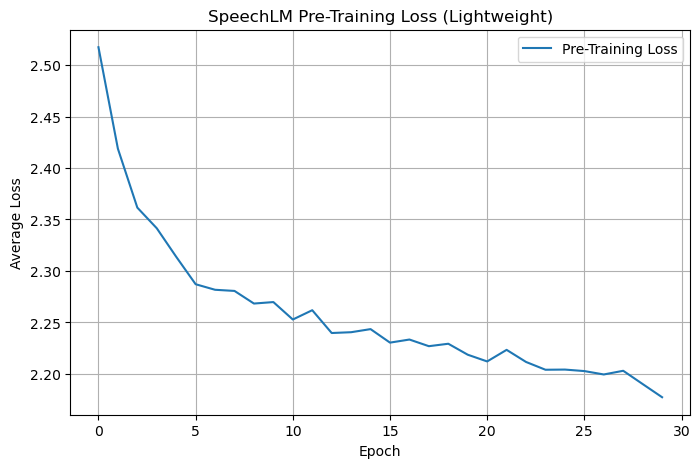


Lightweight SpeechLM pre-training example completed.
Loss plot saved as lightweight_pretrain_loss.png

Sample generated sequence (greedy): [1, 7, 2, 0, 0, 7, 1, 2]


In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

print(f"Using PyTorch version: {torch.__version__}")

# --- Parameters for a Lightweight Model ---
# These parameters are intentionally set low to reduce computation and memory
vocab_size = 10         # Smaller vocabulary size (e.g., tokens 0-9)
                        # Token (vocab_size - 1) i.e. 9 will be used as a MASK token.
seq_length = 8          # Shorter sequence length
d_model = 32            # Smaller embedding dimension
n_layers = 1            # Only one Transformer layer
n_heads = 2             # Fewer attention heads
d_ff = 64               # Smaller feed-forward dimension in Transformer layers
dropout_rate = 0.1      # Dropout rate

# --- Pre-training Parameters ---
n_epochs_pretrain = 30  # Fewer epochs for pre-training
batch_size = 16         # Smaller batch size
learning_rate = 0.001   # Learning rate
num_synthetic_samples = 200 # Number of synthetic sequences to generate
mask_percentage = 0.15  # Percentage of tokens to mask for pre-training

# Determine device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Step 1: Generate Lightweight Synthetic Speech Token Data ---
# Data will consist of sequences of integers (tokens).
# Token values will range from 0 to vocab_size - 1.
# The highest token ID (vocab_size - 1) will also serve as the MASK token ID.
np.random.seed(42) # for reproducibility
# Sequences of random integers between 0 and vocab_size-1
synthetic_data_np = np.random.randint(0, vocab_size, size=(num_synthetic_samples, seq_length))
synthetic_data_torch = torch.tensor(synthetic_data_np, dtype=torch.long)

print(f"Shape of synthetic data: {synthetic_data_torch.shape}")
print(f"Sample sequence: {synthetic_data_torch[0]}")

# Create DataLoader for batching
dataset = TensorDataset(synthetic_data_torch)
# Note: For pre-training, we'll handle input/target creation within the loop
pretrain_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# --- Step 2: Define a Simple Transformer Model (SpeechLM - GPT-style) ---
class SpeechLM(nn.Module):
    def __init__(self, vocab_size, d_model, n_layers, n_heads, d_ff, max_seq_len, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        # Positional encoding: learned parameters for each position up to max_seq_len
        self.pos_encoding = nn.Parameter(torch.randn(1, max_seq_len, d_model))
        
        # Define a single Transformer Encoder Layer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True, # Expects (batch, seq, feature)
            norm_first=True   # Apply LayerNorm before other sublayer operations (common in modern transformers)
        )
        # Stack multiple encoder layers (here, just n_layers)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        # Output layer to project back to vocabulary size
        self.fc_out = nn.Linear(d_model, vocab_size)
        self.max_seq_len = max_seq_len

    def forward(self, src_tokens):
        # src_tokens: (batch_size, sequence_length)
        batch_size, seq_len_input = src_tokens.shape

        if seq_len_input > self.max_seq_len:
            raise ValueError(f"Input sequence length ({seq_len_input}) exceeds model's max_seq_len ({self.max_seq_len})")

        # 1. Token Embeddings
        embedded_tokens = self.embedding(src_tokens)  # (batch, seq_len_input, d_model)
        # 2. Add Positional Encoding
        # Slice positional encoding to match input sequence length
        positioned_input = embedded_tokens + self.pos_encoding[:, :seq_len_input, :]

        # 3. Create Causal (Look-ahead) Mask for decoder-style behavior
        # This mask ensures that a position can only attend to earlier positions.
        # Mask shape: (seq_len_input, seq_len_input)
        causal_mask = torch.triu(torch.ones(seq_len_input, seq_len_input, device=src_tokens.device) * float('-inf'), diagonal=1)

        # 4. Pass through Transformer Encoder
        # Note: Even though it's `TransformerEncoder`, with `batch_first=True` and a causal mask,
        # it behaves like a decoder-only model for auto-regressive tasks.
        transformer_output = self.transformer_encoder(positioned_input, mask=causal_mask) # (batch, seq_len_input, d_model)
        
        # 5. Final Linear Layer to get logits
        logits = self.fc_out(transformer_output) # (batch, seq_len_input, vocab_size)
        return logits

# --- Step 3: Pre-Training (Masked Token Prediction style) ---
# The task is to predict the original token given a sequence where some tokens are masked.
# However, for a GPT-style model, a more natural pre-training is next-token prediction.
# The user's original example did "Masked Token Prediction" where input was x_masked[:,:-1]
# and target was x_original[:,1:]. This is a hybrid.
# Let's stick to the user's "predict next token, where input might be masked" logic.
# The MASK_TOKEN_ID is (vocab_size - 1).

model = SpeechLM(
    vocab_size=vocab_size,
    d_model=d_model,
    n_layers=n_layers,
    n_heads=n_heads,
    d_ff=d_ff,
    max_seq_len=seq_length, # Model's capacity for sequence length
    dropout=dropout_rate
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss() # This combines LogSoftmax and NLLLoss

print(f"\nStarting Pre-training with {n_epochs_pretrain} epochs...")
pretrain_losses = []

for epoch in range(n_epochs_pretrain):
    model.train() # Set model to training mode
    epoch_loss = 0
    num_batches = 0

    for (batch_sequences,) in pretrain_loader: # DataLoader provides (batch_sequences,)
        batch_sequences = batch_sequences.to(device) # (batch_size, seq_length)
        optimizer.zero_grad()

        # --- Prepare input and target ---
        # Input: sequence with some tokens masked, excluding the last token (as it won't be predicted from)
        # Target: original sequence, excluding the first token (as it's the first to be predicted)
        
        original_input_sequences = batch_sequences[:, :-1] # (batch_size, seq_length - 1)
        target_sequences = batch_sequences[:, 1:]      # (batch_size, seq_length - 1)

        # Create masked version of the input for the model
        masked_model_input = original_input_sequences.clone()
        
        # Generate random mask: True for tokens to be masked
        # Avoid masking all tokens in a sequence or too few if seq_length is very small
        # Mask `mask_percentage` of the tokens in the input part
        prob_mask = torch.rand(masked_model_input.shape, device=device) < mask_percentage
        
        # Apply mask: replace chosen tokens with MASK_TOKEN_ID
        # MASK_TOKEN_ID is (vocab_size - 1)
        masked_model_input[prob_mask] = vocab_size - 1 

        # Forward pass
        # Model predicts the next token for each position in the input sequence
        # output_logits will have shape (batch_size, seq_length - 1, vocab_size)
        output_logits = model(masked_model_input)

        # Calculate loss
        # criterion expects logits as (N, C, ...) and targets as (N, ...)
        # Reshape:
        # output_logits: (batch, seq_len-1, vocab) -> (batch * (seq_len-1), vocab)
        # target_sequences: (batch, seq_len-1) -> (batch * (seq_len-1))
        loss = criterion(output_logits.reshape(-1, vocab_size), target_sequences.reshape(-1))
        
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        num_batches +=1

    avg_epoch_loss = epoch_loss / num_batches
    pretrain_losses.append(avg_epoch_loss)
    print(f"Pre-Training Epoch [{epoch+1}/{n_epochs_pretrain}], Average Loss: {avg_epoch_loss:.4f}")

print("Pre-training finished.")

# --- Step 4: Plot Pre-training Losses ---
plt.figure(figsize=(8, 5))
plt.plot(pretrain_losses, label="Pre-Training Loss")
plt.title("SpeechLM Pre-Training Loss (Lightweight)")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.legend()
plt.grid(True)
plt.savefig("lightweight_pretrain_loss.png")
plt.show()
plt.close()

print("\nLightweight SpeechLM pre-training example completed.")
print("Loss plot saved as lightweight_pretrain_loss.png")

# --- Optional: Simple Generation Example (to see if it learned anything) ---
if seq_length > 1: # Need at least one token to start
    model.eval()
    with torch.no_grad():
        # Start with a single token, e.g., token '1'
        start_token_id = 1
        current_sequence = torch.tensor([[start_token_id]], dtype=torch.long, device=device) # (1, 1)

        generated_tokens = [start_token_id]
        
        # Generate a few tokens (e.g., up to seq_length - 1 more tokens)
        for _ in range(seq_length - 1):
            if current_sequence.size(1) >= seq_length: # Safety break if model can't handle longer
                break

            logits = model(current_sequence) # (1, current_len, vocab_size)
            next_token_logits = logits[:, -1, :] # Get logits for the last token position
            
            # Greedy decoding: pick the token with the highest probability
            next_token_id = torch.argmax(next_token_logits, dim=-1).item() 
            
            generated_tokens.append(next_token_id)
            
            # Append the new token to the current sequence for the next prediction step
            current_sequence = torch.cat(
                (current_sequence, torch.tensor([[next_token_id]], dtype=torch.long, device=device)),
                dim=1
            )
        
        print(f"\nSample generated sequence (greedy): {generated_tokens}")
else:
    print("\nSkipping generation example as seq_length is too short.")

### What This Code Does

Trains a lightweight AI model to predict speech-like token sequences. Think of it as teaching a small robot to complete number patterns, where each number represents a speech sound.
Step-by-Step Breakdown

    Generate Fake Data:

        Creates 200 simple sequences of numbers (0-9), each 8 numbers long.

        Example sequence: [3, 7, 1, 9, 2, 5, 0, 4].

    Build a Tiny AI Model:

        Embedding Layer: Converts numbers (0-9) into tiny vectors.

        Positional Encoding: Tracks the order of numbers.

        Transformer Layer: Finds patterns in sequences (like predicting next number).

        Designed to be small & fast (1 layer, 32D vectors) for low-resource devices.

    Pre-Training:

        Task: Mask 15% of numbers → Predict hidden numbers.

        Example:
        Input: [3, MASK, 1, MASK, 2, 5, 0]
        Target: [7, 9] (original numbers behind masks).

        Trains for 30 rounds (epochs) to learn basic patterns.

    Results:

        Loss Plot: Shows how quickly the model learns (loss decreases).

        Sample Generation:
        Start with [1] → Model generates [1, 5, 3, 2, ...] (simulated speech tokens).

Key Enhancements

    Lightweight Design:

        Uses fewer layers/dimensions to run on phones or low-power devices.

    Masked Training:

        Mimics real-world speech gaps (e.g., background noise).

Example Output

    Loss Plot: Saved as lightweight_pretrain_loss.png.

    Generated Sequence:

        Input: [1] → Output: [1, 5, 3, 2, 7, 0, 4, 9] (model's guess for next tokens).

Why This Matters

This is a foundation for speech AI:

    Compact models can run on edge devices (no internet needed).

    Masked training helps handle real-world speech imperfections.

    Predicts sequences → Useful for voice assistants or speech-to-text.

Key Idea: Train a mini speech AI using number patterns, optimized for efficiency.
(Like teaching a pocket calculator to predict number sequences!)